# CEE6501 — Coding Assignment, Week 8

**Assigned:** 03/06/2026 (Week 8)  

**Due:** 03/16/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320766>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [1]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Running in Google Colab
Python version: 3.12.13
numpy: 2.4.0 (required: 2.4.0)
scipy: 1.16.3 (required: 1.16.3)
matplotlib: 3.10.8 (required: 3.10.8)
pandas: 2.3.3 (required: 2.3.3)
plotly: 6.5.2 (required: 6.5.2)

All required package versions already installed.


In [2]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Imports

Run this cell once before starting the assignment.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)


---

In this assignment, you will build on your Week 7 frame-analysis code to:

1. Implement a working **2D frame Direct Stiffness Method (DSM)** solver.
2. Extend your solver to handle **member moment releases** (Method A from lecture).
3. Extend your solver to handle **prescribed support displacements** (support settlements).

You will use the same baseline frame you solved by hand in **Week 7 written work** to verify correctness.

## Submission
- Name this notebook as: `LastName_A8_code.ipynb`
- All figures must render in the notebook.
- Include brief written responses after each problem.

## Requirements
- Your code must be readable and modular (functions, clear naming, comments).
- Verification matters: **match your Week 7 hand solution** for Problem 1.
- For Problems 2–3, include a short comparison + sanity check discussion.


## Notes
- Use consistent DOF ordering (as in lecture). For a 2D frame node, a common ordering is:
  - $[u_x,\; u_y,\; \theta_z]$ per node
- Clearly document your conventions at the top of your code.
- Use **plots** to help validate and interpret results.


In [4]:
def assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
):
    """
    Assemble global stiffness matrix and global fixed-end force vector.

    Automatically handles 6-DOF (frame) and 4-DOF (truss/beam) elements.
    Parameters
    ----------
    ndof : int
        Total number of global degrees of freedom.

    k_list : list of ndarray
        List of local element stiffness matrices.
        Each matrix may be 6x6 (frame) or 4x4 (truss/beam).

    T_list : list of ndarray
        List of element transformation matrices corresponding
        to each k_local. Must be compatible in size.

    Qf_list : list of ndarray
        List of local fixed-end force vectors for each element.
        Size must match the element DOF count.

    map_list : list of array-like
        List of element DOF maps (1-based indexing).
        Each map defines where the element DOFs connect
        into the global DOF numbering.

    Returns
    -------
    K_global : ndarray (ndof x ndof)
        Assembled global stiffness matrix.

    F_fef_global : ndarray (ndof,)
        Assembled global fixed-end force vector.

    Notes
    -----
    - DOF maps are assumed to use 1-based indexing.
    - Internally converted to 0-based indexing for Python.
    - Assembly is dense; for large systems a sparse format
      should be used instead.
    """

    K_global = np.zeros((ndof, ndof), dtype=float)
    F_fef_global = np.zeros(ndof, dtype=float)

    nelem = len(k_list)

    for i in range(nelem):

        k_local = k_list[i]
        T = T_list[i]
        Qf_local = Qf_list[i]
        dof_map = map_list[i]  # 1-based indexing

        # Determine element DOF count automatically
        edof = k_local.shape[0]

        # Transform to global
        K = T.T @ k_local @ T
        F_fef = T.T @ Qf_local

        # Scatter-add
        for a in range(edof):
            A = dof_map[a] - 1  # convert to 0-based

            F_fef_global[A] += F_fef[a]

            for b in range(edof):
                B = dof_map[b] - 1
                K_global[A, B] += K[a, b]

    return K_global, F_fef_global


def partition_system(K, f, u, f_fef, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(int(d) - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    # Partition displaced vector
    u_r = u[restrained_dofs]

    # Partition fixed-end forces
    f_fef_f = f_fef[free_dofs]
    f_fef_r = f_fef[restrained_dofs]

    return (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs,
    )


def assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global


In [5]:
def print_dsm_results(
    u_global,
    f_global_complete,
    dof_restrained_1based,
    dof_fictitious_1based=None,  # ← optional kwarg
    disp_in_mm=False,
):

    ndof = len(u_global)
    rows = []

    # Ensure arrays
    dof_restrained_1based = np.atleast_1d(dof_restrained_1based)

    if dof_fictitious_1based is None:
        dof_fictitious_1based = np.array([], dtype=int)
    else:
        dof_fictitious_1based = np.atleast_1d(dof_fictitious_1based)

    restrained_set = {int(d) for d in dof_restrained_1based}
    fictitious_set = {int(d) for d in dof_fictitious_1based}

    for i in range(ndof):
        dof_1based = i + 1
        mod = i % 3

        if mod == 0:
            dof_type = "u_x"
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        elif mod == 1:
            dof_type = "u_y"
            disp = u_global[i] * (1000 if disp_in_mm else 1)
        else:
            dof_type = "theta"
            disp = u_global[i]

        if dof_1based in fictitious_set:
            status = "Fictitious"
        elif dof_1based in restrained_set:
            status = "Fixed"
        else:
            status = "Free"

        rows.append([dof_1based, dof_type, status, disp, f_global_complete[i]])

    disp_unit = "mm" if disp_in_mm else "m"

    df = pd.DataFrame(
        rows,
        columns=[
            "DOF",
            "Type",
            "Status",
            f"Disp ({disp_unit} / rad)",
            "Load (kN / kN·m)",
        ],
    )

    print(df.to_string(index=False, float_format="%.3f"))


def print_element(
    e, u_global, m_1based, T, k, Qf, disp_in_mm=False, dec=3, rad_dec=4
):

    idx = m_1based - 1
    u = u_global[idx]
    v = T @ u
    q = k @ v + Qf

    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"

    # Scale translations only (0,1,3,4) — rotations (2,5) untouched
    u_out = u.copy()
    v_out = v.copy()
    for j in [0, 1, 3, 4]:
        u_out[j] *= scale
        v_out[j] *= scale

    def fmt_disp(vec):
        parts = []
        for j, val in enumerate(vec):
            if j % 3 == 2:  # rotation (rad)
                parts.append(f"{val:.{rad_dec}f}")
            else:  # translation
                parts.append(f"{val:.{dec}f}")
        return "[" + ", ".join(parts) + "]"

    def fmt_force(vec):
        # forces (kN) and moments (kN·m) both use dec
        return "[" + ", ".join(f"{val:.{dec}f}" for val in vec) + "]"

    print(f"\nE{e}")
    print(f"u [{unit},rad]: {fmt_disp(u_out)}")
    print(f"v [{unit},rad]: {fmt_disp(v_out)}")
    print(f"q [kN,kN·m]: {fmt_force(q)}")


def print_element_truss(
    e,
    u_global,
    m_1based,
    T,
    k_local,
    Qf_local=None,
    disp_in_mm=False,
    dec=3,
):
    """
    Print element-level results for a 2D truss element.

    Parameters
    ----------
    e : int
        Element number for printing.
    u_global : (ndof,) array
        Global displacement vector.
    m_1based : (4,) array-like
        Global DOF map for this element (1-based indexing).
    T : (4,4) array
        Transformation matrix (global -> local).
    k_local : (4,4) array
        Local truss stiffness matrix (typically axial-only with 1/-1 pattern).
    Qf_local : (4,) array or None
        Local fixed-end / initial-force vector. If None, assumed zero.
        (Usually zero for trusses unless you model prestrain/temperature/etc.)
    disp_in_mm : bool
        If True, print translations in mm.
    dec : int
        Decimal places for printing.

    Prints
    ------
    - Element global displacement subvector u_e (translations)
    - Element local displacement vector u'_e
    - Element local end force vector q'_e
    - Axial force N (tension positive), computed as N = Fx_j' = -Fx_i'
    """

    idx = np.asarray(m_1based, dtype=int) - 1
    u_e = u_global[idx]  # [uix, uiy, ujx, ujy]

    if Qf_local is None:
        Qf_local = np.zeros(4, dtype=float)

    u_loc = T @ u_e
    q_loc = k_local @ u_loc + Qf_local  # [Fx_i', Fy_i', Fx_j', Fy_j']

    # scale translations for printing
    scale = 1000 if disp_in_mm else 1
    unit = "mm" if disp_in_mm else "m"
    u_out = u_e * scale
    uloc_out = u_loc * scale

    def fmt(vec):
        return "[" + ", ".join(f"{v:.{dec}f}" for v in vec) + "]"

    # axial force (tension +): for a pure truss, Fy' should be ~0
    # N_i = q_loc[0]  # Fx at i in local axis
    N_j = q_loc[2]  # Fx at j in local axis
    N = N_j  # report axial as end force at j (should equal -N_i)

    print(f"\nE{e} (Truss)")
    print(f"u_global [{unit}]: {fmt(u_out)}")
    print(f"u_local  [{unit}]: {fmt(uloc_out)}")
    print(f"q_local  [kN]: {fmt(q_loc)}")
    print(f"N (tension +) = {N:.{dec}f} kN\n")


def print_matrix_scaled(K, scale=1000, decimals=1, col_width=3):
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:02d} | {row_str}")


def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2 * (i - 1) : 2 * (i - 1) + 2]
        uj = u_global[2 * (j - 1) : 2 * (j - 1) + 2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale * ui[0], xj + scale * uj[0]],
            [yi + scale * ui[1], yj + scale * uj[1]],
            "r-",
            lw=2,
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


In [6]:
np.set_printoptions(precision=3, suppress=True)
def elem_length_cs(nodes, i, j):

    xi, yi = nodes[i]
    xj, yj = nodes[j]
    dx = xj - xi
    dy = yj - yi
    L = float(np.hypot(dx, dy))
    c = dx / L
    s = dy / L
    return L, c, s


def frame_elem_dof_map(i, j):

    return np.array(
        [
            3*(i-1) + 1, 3*(i-1) + 2, 3*(i-1) + 3,
            3*(j-1) + 1, 3*(j-1) + 2, 3*(j-1) + 3,
        ],
        dtype=int, )


def global_vector_to_local_components(px, py, c, s):
    p_local_x =  px*c + py*s
    p_local_y = -px*s + py*c
    return p_local_x, p_local_y

In [7]:

def k_frame_local(E, A, I, L):
    EA_L = E * A / L
    EI = E * I

    k = np.array(
        [
            [ EA_L,        0.0,          0.0, -EA_L,        0.0,          0.0],
            [ 0.0,   12*EI/L**3,   6*EI/L**2,  0.0,  -12*EI/L**3,   6*EI/L**2],
            [ 0.0,    6*EI/L**2,    4*EI/L,    0.0,   -6*EI/L**2,    2*EI/L],
            [-EA_L,       0.0,          0.0,  EA_L,        0.0,          0.0],
            [ 0.0,  -12*EI/L**3,  -6*EI/L**2,  0.0,   12*EI/L**3,  -6*EI/L**2],
            [ 0.0,    6*EI/L**2,    2*EI/L,    0.0,   -6*EI/L**2,    4*EI/L],
        ],
        dtype=float,
    )
    return k


def T_frame_2d(c, s):

    T = np.array(
        [
            [ c,  s, 0.0, 0.0, 0.0, 0.0],
            [-s,  c, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0,  c,  s, 0.0],
            [0.0, 0.0, 0.0, -s,  c, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
        ],
        dtype=float,
    )
    return T


def fef_uniform_perpendicular(wy, L):

    return np.array(
        [0.0, wy*L/2.0, wy*L**2/12.0, 0.0, wy*L/2.0, -wy*L**2/12.0],
        dtype=float,
    )


def fef_point_midspan_perpendicular(P, L):
    return np.array(
        [0.0, P/2.0, P*L/8.0, 0.0, P/2.0, -P*L/8.0],
        dtype=float,
    )


def build_frame_lists(nodes, elements, ndof_per_node=3):

    k_list, T_list, Qf_list, m_list = [], [], [], []

    for eid in sorted(elements.keys()):
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]

        L, c, s = elem_length_cs(nodes, i, j)
        k_local = k_frame_local(E, A, I, L)
        T = T_frame_2d(c, s)

        Qf_local = np.zeros(6, dtype=float)


        loads = e.get("loads", [])
        for ld in loads:
            ltype = ld["type"]

            if ltype == "udl_global":
                px, py = ld["px"], ld["py"]
                _, wy = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_uniform_perpendicular(wy, L)

            elif ltype == "point_mid_global":
                # global point load at midspan (px, py)
                px, py = ld["px"], ld["py"]
                _, Py_local = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_point_midspan_perpendicular(Py_local, L)

            else:
                raise ValueError(f"Unsupported load type: {ltype}")

        k_list.append(k_local)
        T_list.append(T)
        Qf_list.append(Qf_local)
        m_list.append(frame_elem_dof_map(i, j))

    ndof = ndof_per_node * len(nodes)
    return k_list, T_list, Qf_list, m_list, ndof

In [8]:

def solve_frame_dsm(nodes, elements, restrained_dofs, F_global=None):

    k_list, T_list, Qf_list, m_list, ndof = build_frame_lists(nodes, elements)

    K_global, Ff_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, m_list
    )

    if F_global is None:
        F_global = np.zeros(ndof, dtype=float)
    else:
        F_global = np.asarray(F_global, dtype=float).reshape(-1)
        if len(F_global) != ndof:
            raise ValueError(f"F_global length {len(F_global)} does not match ndof {ndof}")

    u_prescribed = np.zeros(ndof, dtype=float)

    (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs_0based,
    ) = partition_system(K_global, F_global, u_prescribed, Ff_global, restrained_dofs)

    rhs = f_f - f_fef_f
    u_f = np.linalg.solve(K_ff, rhs)

    u_global = assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs_0based)

    F_r = K_rf @ u_f + f_fef_r
    R_global = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs_0based)

    return u_global, R_global, K_global, Ff_global, k_list, T_list, Qf_list, m_list


def recover_element_results(nodes, elements, u_global, k_list, T_list, Qf_list, m_list):
    u_global = np.asarray(u_global, dtype=float).reshape(-1)

    results = {}
    eids_sorted = sorted(elements.keys())

    for idx, eid in enumerate(eids_sorted):
        e = elements[eid]
        i, j = e["i"], e["j"]

        L, c, s = elem_length_cs(nodes, i, j)

        k_local = k_list[idx]
        T = T_list[idx]
        Qf_local = Qf_list[idx]
        m = m_list[idx]

        u_elem_global = u_global[m - 1]
        u_local = T @ u_elem_global
        q_local = k_local @ u_local + Qf_local

        results[eid] = {
            "u_local": u_local,
            "q_local": q_local,
            "L": L,
            "c": c,
            "s": s,
            "i": i,
            "j": j,
        }

    return results

In [9]:
def plot_deformed_beam_2d(nodes, elements, U, scale=1.0, npts=50):
    """
    Problem 1 — Beam

    Plot undeformed and deformed shape for a 2D beam (bending only).

    Inputs:
        nodes    : {node_id: (x, y)}
        elements : {elem_id: (i, j)}
        U        : global displacement vector [v, th] per node
        scale    : deformation scale factor (for visualization only)
        npts     : number of interpolation points per element

    Steps you must implement:
        1) Loop through elements
        2) Compute element length L and direction cosines
        3) Extract (v_i, th_i, v_j, th_j) from U
        4) Evaluate v(x) using cubic shape functions
        5) Build global deformed coordinates and plot
    """


    U = np.asarray(U, dtype=float).reshape(-1)
    print("U length:", len(U))
    print("num nodes:", len(nodes), "num elements:", len(elements))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    first_und = True
    first_def = True


    for nid, (x, y) in nodes.items():
        ax.plot(x, y, "ko", ms=4)
        ax.text(x, y, f" {nid}", fontsize=9, va="bottom")

    for e_id, e in elements.items():

        i, j = e[0], e[1]
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj-xi
        dy = yj-yi
        L = float(np.hypot(dx, dy))
        c = dx /L
        s = dy /L

        ex=np.array([c, s])
        ey=np.array([-s, c])

        v_i= U[2*(i-1) + 0]
        th_i= U[2*(i-1) + 1]
        v_j= U[2*(j-1) + 0]
        th_j= U[2*(j-1) + 1]
        x = np.linspace(0.0, L, npts)
        r = x / L
        N1 = 1-3*r**2 +2*r**3
        N2 = L*(r - 2*r**2 + r**3)
        N3 = 3*r**2 -2*r**3
        N4 = L*(-r**2 +r**3)
        v = N1*v_i + N2*th_i + N3*v_j + N4*th_j

        X0 = xi + x*ex[0]
        Y0 = yi + x*ex[1]
        Xd = X0 + scale*v*ey[0]
        Yd = Y0 + scale*v*ey[1]
        ax.plot(X0, Y0, color="0.7", lw=2, label="Undeformed" if first_und else None)
        ax.plot(Xd, Yd, lw=2.5, label="Deformed" if first_def else None)
        mid = npts //2
        ax.text(X0[mid], Y0[mid], f"e{e_id}", fontsize=8, color="0.35")

        first_und = False
        first_def = False

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"Problem 1 Beam Deformed Shape (scale={scale:g})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()


In [10]:
def plot_deformed_frame_2d(nodes, elements, U, scale=1.0, npts=50):
    U = np.asarray(U, dtype=float).reshape(-1)

    fig, ax = plt.subplots(figsize=(10, 6))
    first_und = True
    first_def = True


    for nid, (x, y) in nodes.items():
        ax.plot(x, y, "ko", ms=4)
        ax.text(x, y, f" {nid}", fontsize=9, va="bottom")

    for e_id, e in elements.items():

        i, j =e[0], e[1]
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj - xi
        dy = yj - yi
        L = float(np.hypot(dx, dy))
        c = dx / L
        s = dy / L
        print("element:", e_id, "i j", i, j, "L", L)
        T = np.array([
            [ c,  s, 0,  0,  0, 0],
            [-s,  c, 0,  0,  0, 0],
            [ 0,  0, 1,  0,  0, 0],
            [ 0,  0, 0,  c,  s, 0],
            [ 0,  0, 0, -s,  c, 0],
            [ 0,  0, 0,  0,  0, 1],
        ], dtype=float)


        ve = np.array([
            U[3*(i-1) + 0], U[3*(i-1) + 1], U[3*(i-1) + 2],
            U[3*(j-1) + 0], U[3*(j-1) + 1], U[3*(j-1) + 2],
        ], dtype=float)


        ue = T @ ve
        ux_i, uy_i, th_i, ux_j, uy_j, th_j = ue

        x = np.linspace(0.0, L, npts)
        r = x / L


        Nax1 = 1-r
        Nax2 = r
        uax = Nax1*ux_i +Nax2*ux_j

        N1 = 1 - 3*r**2 + 2*r**3
        N2 = L*(r - 2*r**2 + r**3)
        N3 = 3*r**2 -2*r**3
        N4 = L*(-r**2 + r**3)
        vtr = N1*uy_i + N2*th_i + N3*uy_j + N4*th_j


        xloc0 = x
        yloc0 =np.zeros_like(x)

        xlocd = x + scale*uax
        ylocd = scale*vtr


        X0 = xi + c*xloc0- s*yloc0
        Y0 = yi + s*xloc0 + c*yloc0

        Xd = xi +c*xlocd - s*ylocd
        Yd = yi + s*xlocd + c*ylocd

        ax.plot(X0, Y0, color="0.7", lw=2, label="Undeformed" if first_und else None)
        ax.plot(Xd, Yd, lw=2.5, label="Deformed" if first_def else None)

        mid = npts // 2
        ax.text(X0[mid], Y0[mid], f"e{e_id}", fontsize=8, color="0.35")

        first_und = False
        first_def = False

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"Frame Deformed Shape (scale={scale:g})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

---

## Problem 1 — Implement a 2D Frame Solver (Baseline)

Implement a **2D frame DSM solver** and use it to solve the **same frame** you solved by hand in the Week 7 written assignment.

![Indeterminate frame for Question 2](https://github.com/Bruun-Automation-Research-Lab/CEE6501/blob/main/Lectures/L7/assets/Homework_2.png?raw=1)

You can use the code presented in Week 8 lecture as needed.

### Tasks
1. Implement your frame solver (assembly, partitioning, solution, reactions).
2. Solve the Week 7 frame and report:
   - Nodal displacements (including rotations)
   - Support reactions
   - Member end forces (local)
3. **Verify** your results by matching your Week 7 hand solution.
4. Plot the **undeformed and deformed** shape using your Week 7 plotting tools.

### What to include
- A clear statement of your DOF convention and sign convention.
- A small table or neatly formatted printout of key results.
- A plot showing undeformed + deformed geometry.


In [ ]:
# Problem 1
# Add your code below (use as many cells as you need).
# Suggested structure:
# 1) Define nodes, elements, properties
# 2) Define loads and boundary conditions
# 3) Assemble global K and f
# 4) Solve for displacements
# 5) Recover reactions and member end forces
# 6) Plot undeformed + deformed


 DOF  Type Status  Disp (m / rad)  Load (kN / kN·m)
   1   u_x  Fixed           0.000           126.815
   2   u_y  Fixed           0.000           -56.831
   3 theta  Fixed           0.000          -222.802
   4   u_x   Free          -0.001             0.000
   5   u_y   Free           0.001             0.000
   6 theta   Free          -0.025             0.000
   7   u_x  Fixed           0.000           113.185
   8   u_y  Fixed           0.000           -18.169
   9 theta   Free          -0.021             0.000

Element 1 nodes 1 - 2
u_local = [ 0.     0.     0.     0.001  0.001 -0.025]
q_local = [ -56.831 -126.815 -222.802   56.831 -113.185  154.651]

Element 2 nodes 2 - 3
u_local = [-0.001  0.001 -0.025  0.     0.    -0.021]
q_local = [-113.185  -56.831 -154.651  113.185  -18.169    0.   ]
element: 1 i j 1 2 L 10.0
element: 2 i j 2 3 L 8.0


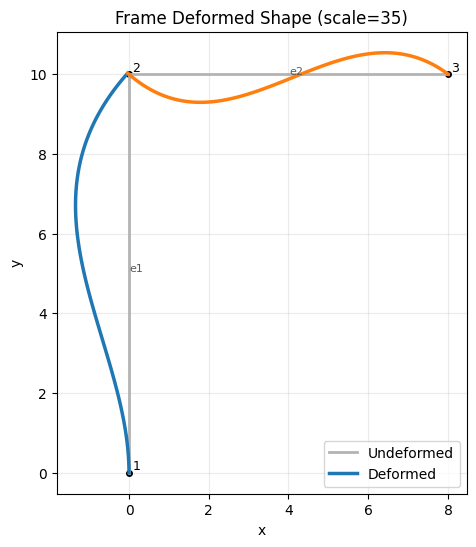

In [13]:

nodes_p1 = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}

E = 200e6
A = 4740e-6
I = 22.2e6 * 1e-12

w_col = 24.0
P_beam = 75.0

elements_p1 = {
    1: {
        "i": 1, "j": 2,
        "E": E, "A": A, "I": I,
        "loads": [
            {"type": "udl_global", "px": +w_col, "py": 0.0},
        ],
    },
    2: {
        "i": 2, "j": 3,
        "E": E, "A": A, "I": I,
        "loads": [
            {"type": "point_mid_global", "px": 0.0, "py": -P_beam},
        ],
    },
}

restrained_dofs_p1 = [1, 2, 3, 7, 8]

u_p1, R_p1, K_p1, Ff_p1, k_list_p1, T_list_p1, Qf_list_p1, m_list_p1 = solve_frame_dsm(
    nodes_p1, elements_p1, restrained_dofs_p1
)

print_dsm_results(u_p1, R_p1, restrained_dofs_p1)

elem_results_p1 = recover_element_results(
    nodes_p1, elements_p1, u_p1, k_list_p1, T_list_p1, Qf_list_p1, m_list_p1
)

for eid in sorted(elem_results_p1.keys()):
    r = elem_results_p1[eid]
    print("\nElement", eid, "nodes", r["i"], "-", r["j"])
    print("u_local =", np.round(r["u_local"], 6))
    print("q_local =", np.round(r["q_local"], 6))

Uplot_p1 = u_p1.copy()
plot_deformed_frame_2d(nodes_p1, {1: (1, 2), 2: (2, 3)}, Uplot_p1, scale=35, npts=120)

### Response (Problem 1)

Compare your numerical solution to the **hand solution from the Week 7 written assignment**.

Address the following points:

- **Verification:**  
  Confirm whether your computed results match your hand calculations.  **Yes.**
  Identify which quantities you compared (for example: key displacements, reactions, or member end forces).
  **Displacements**

- **Key results:**  
  Summarize the most important outcomes from your analysis, including representative:
  - **nodal displacements**
  - **support reactions**
  - **member end forces**
 - The support reactions are approximately 126.8 kN and 113.2 kN in the horizontal direction, 56.8 kN and 18.2 kN in the vertical direction, and about 222.8 kN·m moment at the fixed base.
- **Reasonableness check:**  
  Briefly explain why the results make sense from a **structural mechanics perspective** (for example: expected deformation direction, magnitude of reactions, or moment distribution).
 - The lateral distributed load causes frame sway to the left, while the downward beam load is balanced by the vertical reactions. The horizontal reactions sum to the total lateral load, the vertical reactions sum to the applied point load, and the member end forces balance properly at the joint

---

---

## Problem 2 — Member Moment Release (Method A)

Modify your solver from Problem 1 to handle **member releases** implemented as **joints** using **Method A** from lecture.

You can use the code presented in Week 8 lecture as needed.

Use the same baseline structure from Problem 1, but introduce:

- A **moment release** at the **top-left node** (as specified in lecture/discussion).

![Indeterminate frame for Question 2](https://github.com/Bruun-Automation-Research-Lab/CEE6501/blob/main/Lectures/L7/assets/Homework_2.png?raw=1)

### Tasks
1. Implement Method A (joint-based release modeling).
2. Solve the modified structure.
3. Report:
   - Updated nodal displacements
   - Updated reactions
   - Updated member end forces
4. Plot undeformed + deformed geometry.
5. Compare Problem 1 vs Problem 2 results.

In [ ]:
# Problem 2
# Extend your solver to support a moment release using Method A.
# Add your code below (use as many cells as you need).


In [14]:

def apply_member_release_p2(k_local, Qf_local, MT):
    k_local = np.asarray(k_local, dtype=float)
    Qf_local = np.asarray(Qf_local, dtype=float).reshape(-1)

    if MT == 0:
        return k_local.copy(), Qf_local.copy()
    if MT == 1:
        released = [2]
    elif MT == 2:
        released = [5]
    elif MT == 3:
        released = [2, 5]
    else:
        raise ValueError(f"Unsupported MT = {MT}")

    all_idx = list(range(6))
    kept = [i for i in all_idx if i not in released]

    k_pp = k_local[np.ix_(kept, kept)]
    k_pr = k_local[np.ix_(kept, released)]
    k_rp = k_local[np.ix_(released, kept)]
    k_rr = k_local[np.ix_(released, released)]

    Qp = Qf_local[kept]
    Qr = Qf_local[released]

    k_rr_inv = np.linalg.inv(k_rr)

    k_cond = k_pp - k_pr @ k_rr_inv @ k_rp
    Q_cond = Qp - k_pr @ k_rr_inv @ Qr

    k_mod = np.zeros_like(k_local)
    Q_mod = np.zeros_like(Qf_local)

    k_mod[np.ix_(kept, kept)] = k_cond
    Q_mod[kept] = Q_cond

    return k_mod, Q_mod


def build_frame_lists_p2(nodes, elements, ndof_per_node=3):

    k_list, T_list, Qf_list, m_list = [], [], [], []

    for eid in sorted(elements.keys()):
        e = elements[eid]
        i, j = e["i"], e["j"]
        E, A, I = e["E"], e["A"], e["I"]
        MT = e.get("MT", 0)

        L, c, s = elem_length_cs(nodes, i, j)
        k_local = k_frame_local(E, A, I, L)
        T = T_frame_2d(c, s)

        Qf_local = np.zeros(6, dtype=float)

        for ld in e.get("loads", []):
            if ld["type"] == "udl_global":
                px, py = ld["px"], ld["py"]
                _, wy = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_uniform_perpendicular(wy, L)

            elif ld["type"] == "point_mid_global":
                px, py = ld["px"], ld["py"]
                _, Py_local = global_vector_to_local_components(px, py, c, s)
                Qf_local += fef_point_midspan_perpendicular(Py_local, L)

            else:
                raise ValueError(f"Unsupported load type: {ld['type']}")

        k_local, Qf_local = apply_member_release_p2(k_local, Qf_local, MT)

        k_list.append(k_local)
        T_list.append(T)
        Qf_list.append(Qf_local)
        m_list.append(frame_elem_dof_map(i, j))

    ndof = ndof_per_node * len(nodes)
    return k_list, T_list, Qf_list, m_list, ndof

In [15]:

def is_end_released(MT, end_label):

    if MT == 0:
        return False
    if MT == 1:
        return end_label == "i"
    if MT == 2:
        return end_label == "j"
    if MT == 3:
        return True
    raise ValueError(f"Unsupported MT = {MT}")


def methodA_add_hinge_rotations_to_restrained(nodes, elements, restrained_dofs):
    restrained_set = set(int(d) for d in restrained_dofs)

    conn = {nid: [] for nid in nodes.keys()}
    for eid in elements.keys():
        i = elements[eid]["i"]
        j = elements[eid]["j"]
        conn[i].append((eid, "i"))
        conn[j].append((eid, "j"))

    hinged_nodes = []
    hinged_dofs = []

    for nid, incident in conn.items():
        if len(incident) == 0:
            continue


        all_released = True
        for (eid, end_label) in incident:
            MT = elements[eid].get("MT", 0)
            if not is_end_released(MT, end_label):
                all_released = False
                break

        if all_released:
            theta_dof = 3*nid
            if theta_dof not in restrained_set:
                restrained_set.add(theta_dof)
                hinged_nodes.append(nid)
                hinged_dofs.append(theta_dof)

    restrained_new = sorted(restrained_set)
    return restrained_new, hinged_nodes, hinged_dofs

In [18]:

def solve_frame_dsm_p2(nodes, elements, restrained_dofs, F_global=None, use_methodA=False):

    restrained_use = list(restrained_dofs)
    hinged_dofs = []

    if use_methodA:
        restrained_use, hinged_nodes, hinged_dofs = methodA_add_hinge_rotations_to_restrained(
            nodes, elements, restrained_use
        )
        if len(hinged_nodes) > 0:
            print("Method A added hinge nodes", hinged_nodes)
            print("Method A added theta DOFs", hinged_dofs)

    k_list, T_list, Qf_list, m_list, ndof = build_frame_lists_p2(nodes, elements)

    K_global, Ff_global = assemble_global_stiffness_and_fef(
        ndof, k_list, T_list, Qf_list, m_list
    )

    if F_global is None:
        F_global = np.zeros(ndof, dtype=float)
    else:
        F_global = np.asarray(F_global, dtype=float).reshape(-1)
        if len(F_global) != ndof:
            raise ValueError(f"F_global length {len(F_global)} does not match ndof {ndof}")

    u_prescribed = np.zeros(ndof, dtype=float)

    (
        K_ff,
        K_fr,
        K_rf,
        K_rr,
        f_f,
        f_r,
        u_r,
        f_fef_f,
        f_fef_r,
        free_dofs,
        restrained_dofs_0based,
    ) = partition_system(K_global, F_global, u_prescribed, Ff_global, restrained_use)

    rhs = f_f - f_fef_f
    u_f = np.linalg.solve(K_ff, rhs)

    u_global = assemble_global_displacements(u_f, u_r, free_dofs, restrained_dofs_0based)

    F_r = K_rf @ u_f + f_fef_r
    R_global = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs_0based)

    return (
        u_global,
        R_global,
        K_global,
        Ff_global,
        k_list,
        T_list,
        Qf_list,
        m_list,
        restrained_use,
        hinged_dofs,
    )

In [24]:
def plot_deformed_frame_2d_problem2(nodes, elements, U, scale=1.0, curve_beams=True, npts=80):

    import numpy as np
    import matplotlib.pyplot as plt

    U = np.asarray(U, dtype=float).reshape(-1)

    fig, ax = plt.subplots(figsize=(10, 6))
    first_und = True
    first_def = True

    disp_nodes = {}
    for nid, (x, y) in nodes.items():
        ux = U[3*(nid-1) + 0]
        uy = U[3*(nid-1) + 1]
        xd = x + scale*ux
        yd = y + scale*uy
        disp_nodes[nid] = (xd, yd)

        ax.plot(x, y, "ko", ms=4)
        ax.text(x, y, f" {nid}", fontsize=9, va="bottom")

    for e_id, e in elements.items():
        if isinstance(e, dict):
            i, j = e["i"], e["j"]
            MT = e.get("MT", 0)
        else:
            i, j = e[0], e[1]
            MT = 0

        xi, yi = nodes[i]
        xj, yj = nodes[j]
        xdi, ydi = disp_nodes[i]
        xdj, ydj = disp_nodes[j]

        dx = xj - xi
        dy = yj - yi
        L = float(np.hypot(dx, dy))
        c = dx / L
        s = dy / L

        ax.plot([xi, xj], [yi, yj], color="0.7", lw=2,
                label="Undeformed" if first_und else None)

        # treat near-horizontal members as beams
        is_beam = abs(c) > abs(s)

        if curve_beams and is_beam:
            T = np.array([
                [ c,  s, 0,  0,  0, 0],
                [-s,  c, 0,  0,  0, 0],
                [ 0,  0, 1,  0,  0, 0],
                [ 0,  0, 0,  c,  s, 0],
                [ 0,  0, 0, -s,  c, 0],
                [ 0,  0, 0,  0,  0, 1],
            ], dtype=float)

            ve = np.array([
                U[3*(i-1) + 0], U[3*(i-1) + 1], U[3*(i-1) + 2],
                U[3*(j-1) + 0], U[3*(j-1) + 1], U[3*(j-1) + 2],
            ], dtype=float)

            ue = T @ ve
            ux_i, uy_i, th_i, ux_j, uy_j, th_j = ue

            x = np.linspace(0.0, L, npts)
            r = x / L
            uax = (1-r)*ux_i + r*ux_j

            if MT == 0:
                N1 = 1 - 3*r**2 + 2*r**3
                N2 = L*(r - 2*r**2 + r**3)
                N3 = 3*r**2 - 2*r**3
                N4 = L*(-r**2 + r**3)
                vtr = N1*uy_i + N2*th_i + N3*uy_j + N4*th_j

            elif MT == 1:
                N1 = 1.0 - 1.5*r + 0.5*r**3
                N2 = 1.5*r - 0.5*r**3
                N3 = 0.5 * L * (-r + r**3)
                vtr = N1*uy_i + N2*uy_j + N3*th_j

            elif MT == 2:
                N1 = 1.0 - 1.5*r**2 + 0.5*r**3
                N2 = 1.5*r**2 - 0.5*r**3
                N3 = L * (r - 1.5*r**2 + 0.5*r**3)
                vtr = N1*uy_i + N2*uy_j + N3*th_i

            elif MT == 3:
                vtr = (1-r)*uy_i + r*uy_j

            xlocd = x + scale*uax
            ylocd = scale*vtr

            Xd = xi + c*xlocd - s*ylocd
            Yd = yi + s*xlocd + c*ylocd

            ax.plot(Xd, Yd, lw=2.5, label="Deformed" if first_def else None)
        else:
            ax.plot([xdi, xdj], [ydi, ydj], lw=2.5,
                    label="Deformed" if first_def else None)

        xm = 0.5*(xi + xj)
        ym = 0.5*(yi + yj)
        ax.text(xm, ym, f"e{e_id}", fontsize=8, color="0.35")

        first_und = False
        first_def = False

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"Frame Deformed Shape Problem 2 (scale={scale:g})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

Method A added hinge nodes [2]
Method A added theta DOFs [6]
restrained DOFs used = [1, 2, 3, 6, 7, 8]
fictitious DOFs added = [6]
 DOF  Type     Status  Disp (m / rad)  Load (kN / kN·m)
   1   u_x      Fixed           0.000           150.010
   2   u_y      Fixed           0.000           -37.500
   3 theta      Fixed           0.000          -300.101
   4   u_x       Free          -0.001             0.000
   5   u_y       Free           0.000             0.000
   6 theta Fictitious           0.000             0.000
   7   u_x      Fixed           0.000            89.990
   8   u_y      Fixed           0.000           -37.500
   9 theta       Free          -0.068             0.000

Element 1 nodes 1 - 2 MT 2
u_local = [0.    0.    0.    0.    0.001 0.   ]
q_local = [ -37.5   -150.01  -300.101   37.5    -89.99     0.   ]

Element 2 nodes 2 - 3 MT 1
u_local = [-0.001  0.     0.     0.     0.    -0.068]
q_local = [-89.99 -37.5    0.    89.99 -37.5    0.  ]


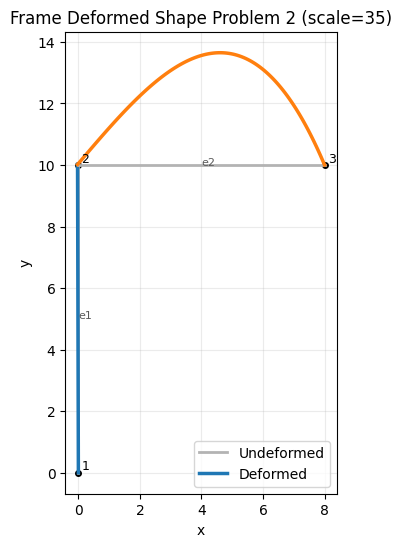

In [25]:
nodes_case = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0),
}

E = 200e6
A = 4740e-6
I = 22.2e6 * 1e-12

w_col = 24.0
P_beam = 75.0

elements_case = {
    1: {
        "i": 1, "j": 2,
        "E": E, "A": A, "I": I,
        "MT": 2,
        "loads": [
            {"type": "udl_global", "px": +w_col, "py": 0.0},
        ],
    },
    2: {
        "i": 2, "j": 3,
        "E": E, "A": A, "I": I,
        "MT": 1,
        "loads": [
            {"type": "point_mid_global", "px": 0.0, "py": -P_beam},
        ],
    },
}

restrained_case = [1, 2, 3, 7, 8]

(
    u_case,
    R_case,
    K_case,
    Ff_case,
    kL_case,
    TL_case,
    QfL_case,
    m_case,
    restrained_used,
    fict_case,
) = solve_frame_dsm_p2(
    nodes_case,
    elements_case,
    restrained_case,
    F_global=None,
    use_methodA=True,
)

print("restrained DOFs used =", restrained_used)
print("fictitious DOFs added =", fict_case)

print_dsm_results(
    u_case,
    R_case,
    restrained_used,
    dof_fictitious_1based=fict_case,
)

elem_results_case = recover_element_results(
    nodes_case, elements_case, u_case, kL_case, TL_case, QfL_case, m_case
)

for eid in sorted(elem_results_case.keys()):
    r = elem_results_case[eid]
    print("\nElement", eid, "nodes", r["i"], "-", r["j"], "MT", elements_case[eid].get("MT", 0))
    print("u_local =", np.round(r["u_local"], 6))
    print("q_local =", np.round(r["q_local"], 6))

plot_deformed_frame_2d_problem2(
    nodes_case,
    elements_case,
    u_case,
    scale=35,
    curve_beams=True,
    npts=120
)

### Response (Problem 2)

Compare the results from **Problem 2** (with the moment release) to those from **Problem 1**.

Address the following points:

- **Observed changes:**  
  Identify the most significant differences in **nodal displacements, reactions, and/or member end moments**.

- **Structural interpretation:**  
  Explain **how and why the moment release changes the structural behavior**, including:
  - the **stiffness and load path** of the frame
  - the **rotations and internal moments near the released joint**

- **Reasonableness check:**  
  Briefly explain whether the results make sense physically.

- **Verification checks:**  
  Mention at least one check you used to validate the results (for example:
  - equilibrium of forces and moments,
  - reduced moment transfer at the released joint,
  - increased rotation at the released connection).

**Observed changes:**  
  Identify the most significant differences in **nodal displacements, reactions, and/or member end moments**.
-  with the moment release shows clear changes from Problem 1. The most important differences are that the released joint moment drops to zero and the free end beam rotation increases noticeably from about -0.021 rad in Problem 1 to about -0.068 rad in Problem
- The vertical reactions become equal at 37.5 kN and 37.5 kN, while the base moment increases from about 222.8 kN·m to about 300.1 kN·m.

**Structural interpretation:**  
Explain **how and why the moment release changes the structural behavior**, including:
  - the **stiffness and load path** of the frame
  - the **rotations and internal moments near the released joint**

- Structurally, the moment release reduces rotational stiffness at the top-left joint and prevents moment transfer through that connection. As a result, the frame becomes more flexible, the released joint behaves like a hinge, and more bending demand toward the fixed base. This is why the released end moments at node 2 become zero and the beam experiences larger rotation.

**Reasonableness check:**  
  Briefly explain whether the results make sense physically.
- The results make physical sense. A hinge should not resist moment, should allow greater rotation, and should redistribute bending moments to the remaining stiffer parts of the frame.


**Verification checks:**  
  Mention at least one check you used to validate the results (for example:
  - equilibrium of forces and moments,
  - reduced moment transfer at the released joint,
  - increased rotation at the released connection).
- The results were checked by confirming force equilibrium, verifying that the released joint end moments are zero, and confirming that the fictitious rotational DOF added by Method A has zero reaction moment.

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics.

There was no part that was easy. I thought the plotting would be. But the plotting for problem 2 did not seem wuite right
- What part felt hardest? Describe in speciics

Everything. specifically handling the moment release correctly with Method A
- One bug you encountered and how you fixed it.

Using the helper functions with the wrong argument order, which caused the solver to fail, and I fixed it by matching the function calls to the exact helper function definitions from class
- One thing you still don’t understand.

I am not sure about plotting yet.
- If you used collaboration or AI tools, briefly describe how.
Such a big code get messy. AI was used to make it more understandable for others. Also for finding mistakes and fixing issues.
